In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

#(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()



In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/Othercomputers/Meu MacBook Air/Documents/Fiap/Mentoria/6IADT/vc-fashion-mnist/archive (1).zip'
extract_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Arquivo extraído para: {extract_dir}")

Arquivo extraído para: /content/


In [ ]:
from pathlib import Path
from PIL import Image
img = []
def load_split(root):
    X, y = [], []
    root = Path(root)
    for cdir in sorted([p for p in root.iterdir() if p.is_dir()]):
        label = int(cdir.name)
        for f in sorted(cdir.iterdir()):
            img = Image.open(f)
            X.append(img)
            y.append(label)
    return np.stack(X, axis=0), np.asarray(y, dtype=np.uint8)            # (N,28,28), (N,)

x_train, y_train = load_split("/content/train")                      # carrega split oficial de treino
x_test,  y_test  = load_split("/content/test")                       # carrega split oficial de teste

In [ ]:
x_train[0]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 222, 209, 203, 215, 200,   0,  70,  98,
          0, 103,  59,  68,  71,  49,   0, 219, 206, 214, 210, 250,  38,
          0,   0],
       [  0,   0,   0,   0, 247, 218, 212, 210, 215, 214,   0, 254, 243,
        139, 255, 174, 251, 255, 205,   0, 215, 217, 214, 208, 220,  95,
          0,   0],
       [  0,   0,   0,  45, 226, 214, 214, 215, 224, 205,   0,  42,  35,
         60,  16,  17,  12,  13,  70,   0, 189, 216, 212, 206, 212, 156,
          0,   0],
       [  0,   0,   0, 164, 235, 214, 211, 220, 216, 201,  52,  71,  89,
         94,  83,  78,  70,  76,  92,  87, 206, 207, 222, 213, 219, 208,
          0,   0],
       [  0,   0,   0, 106, 187, 223, 237, 248, 211, 198, 252, 250, 248,
        245, 248, 252, 253, 250, 252, 239, 201, 212, 225, 215, 193, 113,
          0,   0],
       [  0,   0,   0,   0,   0,  17,  54, 159, 222, 193, 208, 192, 197,
        200, 200, 200, 200, 201, 203, 195, 210, 165,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  47, 225, 192, 214, 203, 206,
        204, 204, 205, 206, 204, 212, 197, 218, 107,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   1,   6,   0,  46, 212, 195, 212, 202, 206,
        205, 204, 205, 206, 204, 212, 200, 218,  91,   0,   3,   1,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,  11, 197, 199, 205, 202, 205,
        206, 204, 205, 207, 204, 205, 205, 218,  77,   0,   5,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   3,   0,   2, 191, 198, 201, 205, 206,
        205, 205, 206, 209, 206, 199, 209, 219,  74,   0,   5,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   2,   0,   0, 188, 197, 200, 207, 207,
        204, 207, 207, 210, 208, 198, 207, 221,  72,   0,   4,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   2,   0,   0, 215, 198, 203, 206, 208,
        205, 207, 207, 210, 208, 200, 202, 222,  75,   0,   4,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   0, 212, 198, 209, 206, 209,
        206, 208, 207, 211, 206, 205, 198, 221,  80,   0,   3,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   0, 204, 201, 205, 208, 207,
        205, 211, 205, 210, 210, 209, 195, 221,  96,   0,   3,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   0, 202, 201, 205, 209, 207,
        205, 213, 206, 210, 209, 210, 194, 217, 105,   0,   2,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   0, 204, 204, 205, 208, 207,
        205, 215, 207, 210, 208, 211, 193, 213, 115,   0,   2,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 204, 207, 207, 208, 206,
        206, 215, 210, 210, 207, 212, 195, 210, 118,   0,   2,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   0, 198, 208, 208, 208, 204,
        207, 212, 212, 210, 207, 211, 196, 207, 121,   0,   1,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   

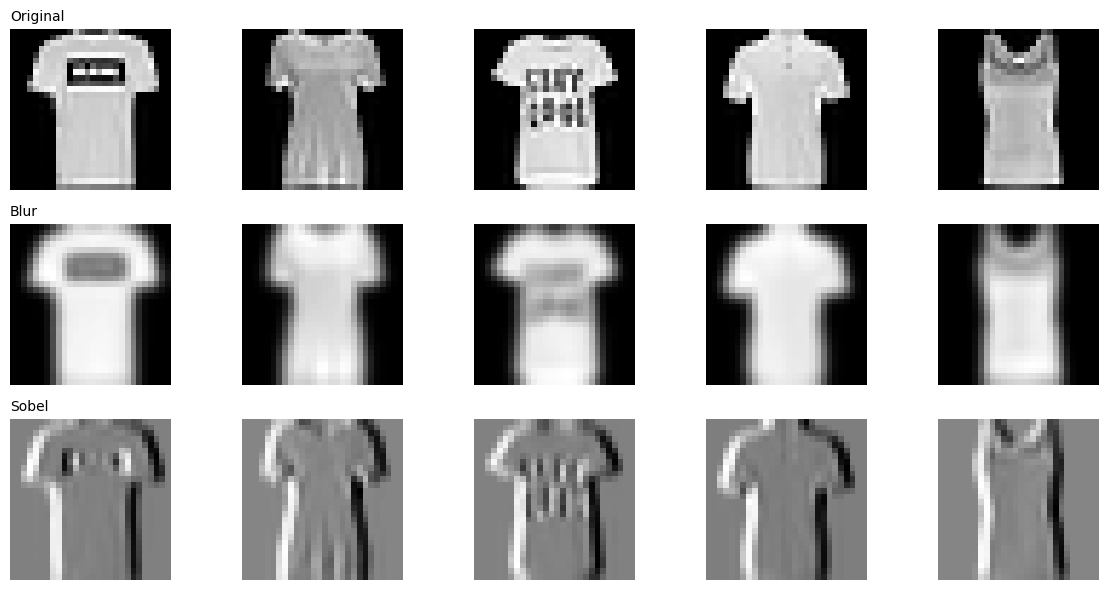

In [ ]:
sample_images = x_train[:5]

filtered_images = {
    'original': sample_images,
    'blurred': np.array([cv2.GaussianBlur(img, (5, 5), 0) for img in sample_images]),
    'sobel': np.array([cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) for img in sample_images])
}

fig, axs = plt.subplots(3, 5, figsize=(12, 6))
titles = ['Original', 'Blur', 'Sobel']

for i in range(5):
    axs[0, i].imshow(filtered_images['original'][i], cmap='gray')
    axs[1, i].imshow(filtered_images['blurred'][i], cmap='gray')
    axs[2, i].imshow(filtered_images['sobel'][i], cmap='gray')
    for j in range(3): axs[j, i].axis('off')

for row, title in zip(axs[:, 0], titles):
    row.set_title(title, fontsize=10, loc='left')

plt.tight_layout()
plt.show()


In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0


In [ ]:
x_train_flat = x_train_norm.reshape(-1, 28*28)
x_test_flat = x_test_norm.reshape(-1, 28*28)


In [ ]:
len(x_train_flat[0])

784

In [ ]:

dt = tree.DecisionTreeClassifier(random_state=42)
dt.fit(x_train_flat, y_train)
acc_dt = accuracy_score(y_test, dt.predict(x_test_flat))
print(f"Acurácia - Decision Tree: {acc_dt:.4f}")

Acurácia - Decision Tree: 0.7888


In [ ]:
from tensorflow.keras.optimizers import Adam

model_dense = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

optimizer_dense = Adam(learning_rate=0.001)

model_dense.compile(optimizer=optimizer_dense,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

model_dense.fit(x_train_flat, y_train, epochs=5, batch_size=64)

loss_dense, acc_dense = model_dense.evaluate(x_test_flat, y_test)
print(f"Acurácia - Rede Neural Tradicional: {acc_dense:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7633 - loss: 0.6966
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8616 - loss: 0.3870
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8757 - loss: 0.3424
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8876 - loss: 0.3121
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8880 - loss: 0.3012
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8522 - loss: 0.3968
Acurácia - Rede Neural Tradicional: 0.8752


In [ ]:
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.fit(x_train_cnn, y_train, epochs=5, batch_size=64)
loss_cnn, acc_cnn = model_cnn.evaluate(x_test_cnn, y_test)
print(f"Acurácia - CNN: {acc_cnn:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.7448 - loss: 0.7216
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.8721 - loss: 0.3510
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.8933 - loss: 0.2955
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.9030 - loss: 0.2664
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.9119 - loss: 0.2403
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9046 - loss: 0.2871
Acurácia - CNN: 0.8943


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

# suppose you already did:
# (x_train, y_train), (x_test, y_test) = load_fashion_mnist_png("fashion-mnist-png")

# 1. convert numpy arrays -> torch tensors
x_train_t = torch.from_numpy(x_train).unsqueeze(1).float() / 255.0   # (N,1,28,28), float in [0,1]
y_train_t = torch.from_numpy(y_train).long()

x_test_t = torch.from_numpy(x_test).unsqueeze(1).float() / 255.0
y_test_t = torch.from_numpy(y_test).long()

# 2. wrap in TensorDataset
train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset  = TensorDataset(x_test_t, y_test_t)

# 3. DataLoaders (same interface as torchvision)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 4. device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
class DenseNet(nn.Module):
    def __init__(self):
        super(DenseNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

dense_model = DenseNet().to(device)
optimizer_dense = optim.Adam(dense_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train_model(model, optimizer, criterion, loader):
    model.train()
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

def evaluate_model(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
    return correct / len(loader.dataset)


In [ ]:
for epoch in range(5):
    train_model(dense_model, optimizer_dense, criterion, train_loader)

acc_dense_pt = evaluate_model(dense_model, test_loader)
print(f"Acurácia - Rede Neural Tradicional (PyTorch): {acc_dense_pt:.4f}")


Acurácia - Rede Neural Tradicional (PyTorch): 0.8661


In [ ]:
class CNNNet(nn.Module):
    def __init__(self):
        super(CNNNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64*7*7, 64)
        self.out = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 64*7*7)
        x = F.relu(self.fc1(x))
        return self.out(x)

cnn_model = CNNNet().to(device)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

for epoch in range(5):
    train_model(cnn_model, optimizer_cnn, criterion, train_loader)

acc_cnn_pt = evaluate_model(cnn_model, test_loader)
print(f"Acurácia - CNN (PyTorch): {acc_cnn_pt:.4f}")


Acurácia - CNN (PyTorch): 0.9097


In [ ]:
print("\nComparação de Acurácia:")
print(f"Decision Tree:            {acc_dt:.4f}")
print(f"Rede Neural Tradicional TF: {acc_dense:.4f}")
print(f"Rede Neural Tradicional PT: {acc_dense_pt:.4f}")
print(f"Rede Neural Convolucional TF: {acc_cnn:.4f}")
print(f"Rede Neural Convolucional pT: {acc_cnn_pt:.4f}")


Comparação de Acurácia:
Decision Tree:            0.7888
Rede Neural Tradicional TF: 0.8752
Rede Neural Tradicional PT: 0.8661
Rede Neural Convolucional TF: 0.8943
Rede Neural Convolucional pT: 0.9097
